# EMTA andmete analüüs

## Ettevlmistused

In [2]:
from typing import Callable

import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Andmetega tutvumine

In [3]:
data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
data_raw_this_year

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192.0,2141341.0,...,1213643.0,1131417.0,34309154,30413704.0,23282177.0,21724706.0,254.0,243.0,244.0,240.0
1,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,NaN,NaN,...,NaN,NaN,19993085,NaN,NaN,NaN,236.0,NaN,NaN,NaN
2,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980.0,38723.0,...,38979.0,36127.0,236677,235518.0,206299.0,280010.0,11.0,11.0,10.0,10.0
3,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,NaN,NaN,...,NaN,NaN,299247,NaN,NaN,NaN,11.0,NaN,NaN,NaN
4,10.04.2026,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342.0,635.0,...,0.0,NaN,1941,2925.0,9273.0,906.0,NaN,NaN,NaN,NaN


In [4]:
duckdb.sql("""
    FROM 'tasutud_maksud_varasemad_aastad.csv'
    LIMIT 5
""").df()

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),None,2022,<NA>,288,<NA>,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),None,2023,<NA>,288,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),None,2024,288,52,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-04-10,01834575,"KUNDERI 24, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),None,2024,<NA>,<NA>,268,...,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,1300554,1645555,1185273,...,923188,950362,22930261,31976194,26140614,31599227,214,228,231,232


In [5]:
# Kontrollime, kas tulpade nimed on mõlemas failis samad
data_raw_new = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
data_raw_old = pd.read_csv("tasutud_maksud_varasemad_aastad.csv", nrows=5)
data_raw_new.columns == data_raw_old.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [6]:
data_raw = duckdb.sql("""
    FROM 'tasutud_maksud_kaesolev_aasta.csv'
    UNION ALL
    FROM 'tasutud_maksud_varasemad_aastad.csv'
""").df()
data_raw

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192,2141341,...,1213643,1131417,34309154,30413704,23282177,21724706,254,243,244,240
1,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,<NA>,<NA>,...,<NA>,<NA>,19993085,<NA>,<NA>,<NA>,236,<NA>,<NA>,<NA>
2,2026-04-10,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980,38723,...,38979,36127,236677,235518,206299,280010,11,11,10,10
3,2026-04-10,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,<NA>,<NA>,...,<NA>,<NA>,299247,<NA>,<NA>,<NA>,11,<NA>,<NA>,<NA>
4,2026-04-10,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342,635,...,0,<NA>,1941,2925,9273,906,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070347,2026-04-10,OO000012,HANDELSBOLAGET KORSVÄGEN FÖRVALTING,Mitteresident,None,None,2024,2,13,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1070348,2026-04-10,OO000015,TRUST FINANCING AB,Mitteresident,None,None,2024,<NA>,83,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1070349,2026-04-10,QQ000003,RAUMASTER OY,Mitteresident,None,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,24114,18514,21953,...,21802,22937,26908,26851,86902,23302,3,3,3,3
1070350,2026-04-10,QQ000003,RAUMASTER OY,Mitteresident,None,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2023,23447,20816,23767,...,24487,23491,18309,19522,7596,47353,3,3,3,4


In [7]:
data_unpivot = duckdb.sql("""
WITH base AS (
    SELECT
        "Andmete seis",
        "Registrikood",
        "Nimi",
        "Liik",
        "Maakond",
        "Tegevusala",
        "Aasta",
        "Riiklikud maksud I kv" AS riiklikud_maksud_1,
        "Riiklikud maksud II kv" AS riiklikud_maksud_2,
        "Riiklikud maksud III kv" AS riiklikud_maksud_3,
        "Riiklikud maksud IV kv" AS riiklikud_maksud_4,
        "Tööjõumaksud I kv" AS toojou_maksud_1,
        "Tööjõumaksud II kv" AS toojou_maksud_2,
        "Tööjõumaksud III kv" AS toojou_maksud_3,
        "Tööjõumaksud IV kv" AS toojou_maksud_4,
        "Käive I kv" AS kaive_1,
        "Käive II kv" AS kaive_2,
        "Käive III kv" AS kaive_3,
        "Käive IV kv" AS kaive_4,
        "Töötajate arv I kv" AS tootajad_1,
        "Töötajate arv II kv" AS tootajad_2,
        "Töötajate arv III kv" AS tootajad_3,
        "Töötajate arv IV kv" AS tootajad_4
    FROM data_raw
)
UNPIVOT base
ON
    (riiklikud_maksud_1, toojou_maksud_1, kaive_1, tootajad_1),
    (riiklikud_maksud_2, toojou_maksud_2, kaive_2, tootajad_2),
    (riiklikud_maksud_3, toojou_maksud_3, kaive_3, tootajad_3),
    (riiklikud_maksud_4, toojou_maksud_4, kaive_4, tootajad_4)
INTO
    NAME kvartal
    VALUE riiklikud_maksud, toojoumaksud, kaive, tootajate_arv;
""").df()
data_unpivot[:3]

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_1_toojou_maksud_1_kaive_1_too...,1723565,1259900,34309154,254
1,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_2_toojou_maksud_2_kaive_2_too...,2038192,1229742,30413704,243
2,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_3_toojou_maksud_3_kaive_3_too...,2141341,1213643,23282177,244


In [8]:
def eralda_maakond(maakond: str) -> str:
    return maakond.split(" ( ")[0]

def eralda_kov(maakond: str) -> str:
    return maakond.split(" ( ")[1][:-2]
    return maakond.split(" ( ")[1].replace(" )", "")

def puhasta_kvartal(kvartal: str) -> int:
    return int(kvartal[-1])

def peamine_tegevusala(tegevusalad: str) -> str:
    return tegevusalad.split(";")[0]

def _register_duckdb_function(duckdb_function_name: str, function: Callable) -> None:
    try:
        duckdb.remove_function(duckdb_function_name)
    except:
        pass
    duckdb.create_function(duckdb_function_name, function)

_register_duckdb_function(duckdb_function_name="eralda_maakond", function=eralda_maakond)
_register_duckdb_function(duckdb_function_name="eralda_kov", function=eralda_kov)
_register_duckdb_function(duckdb_function_name="puhasta_kvartal", function=puhasta_kvartal)
_register_duckdb_function(duckdb_function_name="peamine_tegevusala", function=peamine_tegevusala)


/var/folders/d5/v1n8g5qn4hvbs41713n9bhkw0000gn/T/ipykernel_69989/3844919807.py:19: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  duckdb.create_function(duckdb_function_name, function)


In [9]:
eralda_maakond("Lääne-Viru ( Viru-Nigula vald )  (  Kukk ja kana")

'Lääne-Viru'

In [10]:
eralda_kov("Lääne-Viru ( Viru-Nigula vald )")

'Viru-Nigula vald'

In [11]:
"Lääne-Viru ( Viru-Nigula vald ) ( Kukk ja kana".split(" ( ")[1]

'Viru-Nigula vald )'

In [12]:
data = duckdb.sql("""
    SELECT
        Registrikood AS registrikood,
        Nimi AS nimi,
        Liik AS liik,
        eralda_maakond(Maakond) AS maakond,
        eralda_kov(Maakond) AS kov,
        peamine_tegevusala(Tegevusala) AS tegevusala,
        Aasta AS aasta,
        puhasta_kvartal(kvartal) AS kvartal,
        riiklikud_maksud,
        toojoumaksud,
        kaive,
        tootajate_arv
    FROM data_unpivot   
""").df()
data

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


## Avastuslik andmeanalüüs (*exploratory analysis*)

In [13]:
duckdb.sql("""
    SUMMARIZE data
""")

┌──────────────────┬─────────────┬──────────────────────────────┬────────────────────┬───────────────┬────────────────────┬────────────────────┬─────────┬─────────┬─────────┬────────┬─────────────────┐
│   column_name    │ column_type │             min              │        max         │ approx_unique │        avg         │        std         │   q25   │   q50   │   q75   │ count  │ null_percentage │
│     varchar      │   varchar   │           varchar            │      varchar       │     int64     │      varchar       │      varchar       │ varchar │ varchar │ varchar │ int64  │  decimal(9,2)   │
├──────────────────┼─────────────┼──────────────────────────────┼────────────────────┼───────────────┼────────────────────┼────────────────────┼─────────┼─────────┼─────────┼────────┼─────────────────┤
│ registrikood     │ VARCHAR     │ 10000018                     │ QQ000003           │         98931 │ NULL               │ NULL               │ NULL    │ NULL    │ NULL    │ 943934 │         

In [14]:
duckdb.sql("""
    SELECT
        maakond,
        count(DISTINCT registrikood) AS ettevotete_arv,
        round(avg(kaive) / 3)::int AS keskmine_kuine_kaive,
        round(avg(kaive))::int AS keskmine_kvartaalne_kaive
    FROM data
    WHERE aasta = 2026 AND kvartal = 1
    GROUP BY maakond
    ORDER BY keskmine_kuine_kaive DESC
""")

┌────────────┬────────────────┬──────────────────────┬───────────────────────────┐
│  maakond   │ ettevotete_arv │ keskmine_kuine_kaive │ keskmine_kvartaalne_kaive │
│  varchar   │     int64      │        int32         │           int32           │
├────────────┼────────────────┼──────────────────────┼───────────────────────────┤
│ NULL       │            141 │               254183 │                    762548 │
│ Harju      │          31202 │               201933 │                    605799 │
│ Järva      │            936 │               124710 │                    374131 │
│ Tartu      │           6616 │               120512 │                    361536 │
│ Lääne-Viru │           2095 │               105897 │                    317690 │
│ Viljandi   │           1723 │                88801 │                    266402 │
│ Valga      │            839 │                81555 │                    244664 │
│ Jõgeva     │            949 │                80395 │                    241184 │
│ Id

<Axes: xlabel='tootajate_arv', ylabel='tegevusala'>

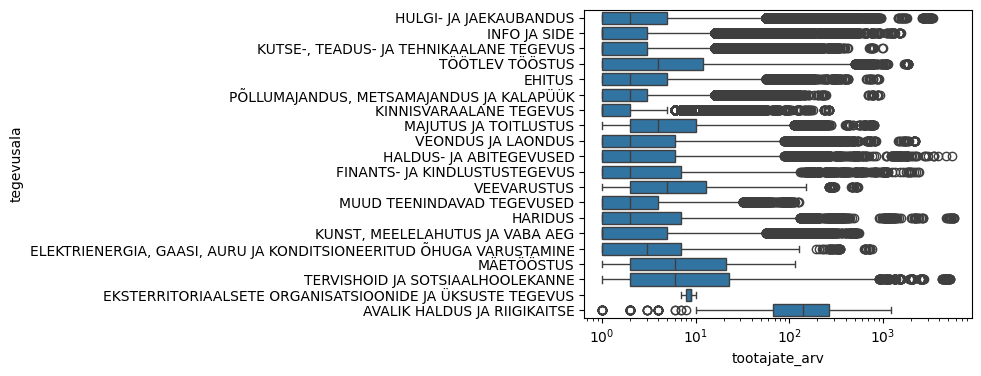

In [15]:
plt.figure(1, figsize=(5, 4))
sns.boxplot(data, y="tegevusala", x="tootajate_arv", log_scale=10)


In [16]:
data.to_csv("emta_data.csv", index=False)

## Töötajata ja käibe suhe

In [17]:
data

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


<Axes: xlabel='tootajate_arv', ylabel='kaive'>

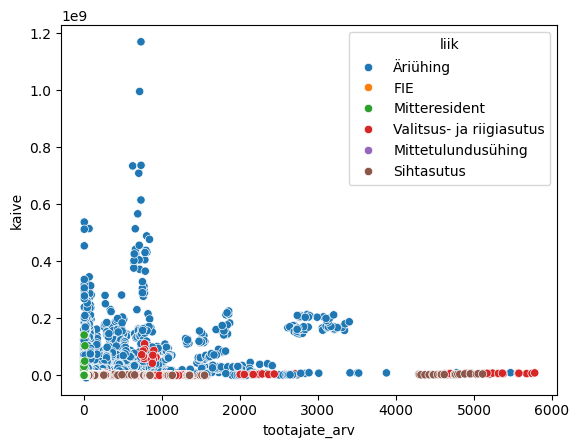

In [26]:
sns.scatterplot(data, x="tootajate_arv", y="kaive", hue="liik")

In [52]:
avg_revenue = duckdb.sql("""
    SELECT
        nimi,
        avg(round(kaive / 3))::int AS avg_kaive,
        avg(round(tootajate_arv))::int AS tootajate_arv,
        any_value(liik) AS liik,
        any_value(maakond) AS maakond
    FROM data
    GROUP BY nimi
    ORDER BY avg_kaive DESC
""").df()
avg_revenue

,nimi,avg_kaive,tootajate_arv,liik,maakond
0,EESTI ENERGIA AS,191064034,685,Äriühing,Harju
1,BOLT OPERATIONS OÜ,117072399,773,Äriühing,Harju
2,ORLEN EESTI OÜ,107338365,7,Äriühing,Harju
3,AS ELENGER GRUPP,85115652,80,Äriühing,Harju
4,TOYOTA BALTIC AS,73011311,43,Äriühing,Harju
...,...,...,...,...,...
80884,SMALLMIX OÜ,-5273,2,Äriühing,Harju
80885,KE KONSULT OÜ,-7337,2,Äriühing,Harju
80886,24/7 KAUBANDUS OÜ,-15756,4,Äriühing,Harju
80887,PROFI LOGISTIC OÜ,-15985,1,Äriühing,Harju


<Axes: xlabel='tootajate_arv', ylabel='avg_kaive'>

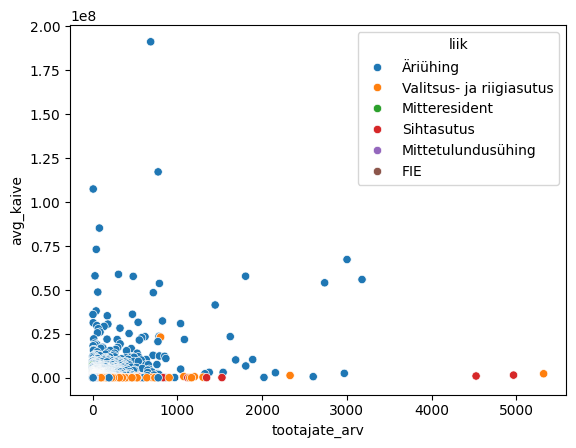

In [42]:
sns.scatterplot(avg_revenue, x="tootajate_arv", y="avg_kaive", hue="liik")

<Axes: xlabel='tootajate_arv', ylabel='Density'>

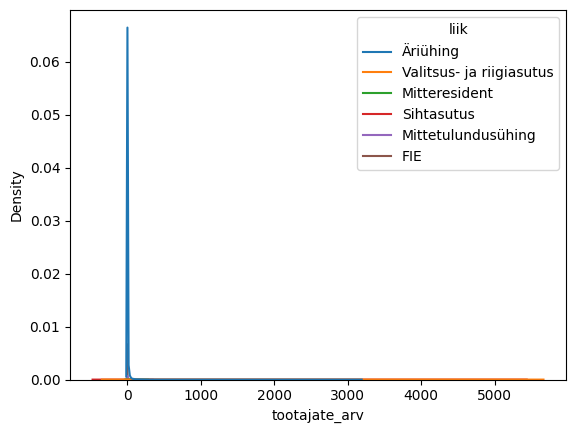

In [43]:
sns.kdeplot(avg_revenue, x="tootajate_arv", hue="liik")

In [49]:
data.columns

Index(['registrikood', 'nimi', 'liik', 'maakond', 'kov', 'tegevusala', 'aasta',
       'kvartal', 'riiklikud_maksud', 'toojoumaksud', 'kaive',
       'tootajate_arv'],
      dtype='object')

/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


<Axes: xlabel='tootajate_arv', ylabel='toojoumaksud'>

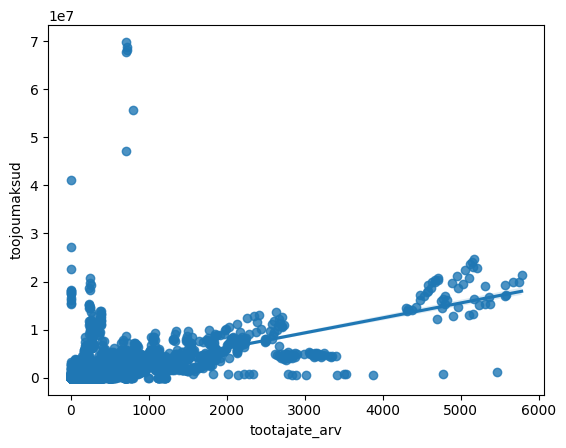

In [51]:
sns.regplot(data, x="tootajate_arv", y="toojoumaksud")

<Axes: xlabel='avg_kaive', ylabel='maakond'>

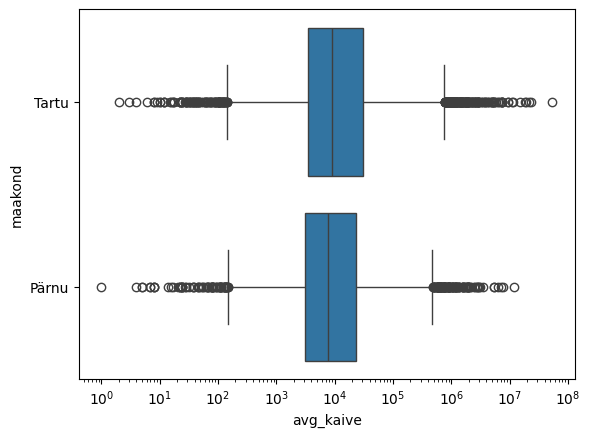

In [54]:
sns.boxplot(
    avg_revenue[avg_revenue["maakond"].isin(["Tartu", "Pärnu"])],
    x="avg_kaive",
    y="maakond",
    log_scale=10
)

In [62]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    duckdb.sql("SELECT avg_kaive FROM avg_revenue WHERE maakond = 'Tartu' AND avg_kaive IS NOT NULL").df()["avg_kaive"],
    duckdb.sql("SELECT avg_kaive FROM avg_revenue WHERE maakond = 'Pärnu' AND avg_kaive IS NOT NULL").df()["avg_kaive"],
    alternative='two-sided'
)
float(p)
print(f"{p:.15f}")


0.000000000058441


# Muud värgid

In [18]:
duckdb.sql("""
    SELECT DISTINCT Maakond FROM data_raw
""")

┌──────────────────────────────────┐
│             Maakond              │
│             varchar              │
├──────────────────────────────────┤
│ Viljandi ( Põhja-Sakala vald )   │
│ Ida-Viru ( Narva linn )          │
│ Lääne-Viru ( Väike-Maarja vald ) │
│ Pärnu ( Kihnu vald )             │
│ Harju ( Anija vald )             │
│ Harju ( Saku vald )              │
│ NULL                             │
│ Rapla ( Kehtna vald )            │
│ Jõgeva ( Põltsamaa vald )        │
│ Pärnu ( Tori vald )              │
│          ·                       │
│          ·                       │
│          ·                       │
│ Rapla ( Märjamaa vald )          │
│ Saare ( Ruhnu vald )             │
│ Lääne-Viru ( Rakvere linn )      │
│ Tartu ( Tartu vald )             │
│ Tartu ( Kastre vald )            │
│ Harju ( Loksa linn )             │
│ Pärnu ( Põhja-Pärnumaa vald )    │
│ Lääne-Viru ( Viru-Nigula vald )  │
│ Harju ( Maardu linn )            │
│ Harju ( Kuusalu vald )           │
├

In [19]:
print("Hello, World.")
print("Hello, World!")
print("Hello, World?")
print("Hello, World...")

Hello, World.
Hello, World!
Hello, World?
Hello, World...


In [20]:
def hw(ending: str, count: int):
    for i in range(count):
        print(f"Hello, World{ending}")

# Masin ütleb Ahhah. Aga masin midagi ei tee.

In [21]:
hw(".", 3)
hw("!", 1)
hw("?", 2)
hw("...", 1)

Hello, World.
Hello, World.
Hello, World.
Hello, World!
Hello, World?
Hello, World?
Hello, World...


In [22]:
"""
Eerik Sven Puudist isikukoodiga 39904201425, edaspidi kui volitaja
ning Katrin Kuldratas 49804129876 kui volitatu

lepivad kokku alljärgnevas.

Volitaja volitab volitatu võtma minu nimel välja postipaki.
"""

def volita_pakki_valja_votma(kes_volitab, keda_volitab, paki_nr):
    vota_pakk_valja()

volita_pakki_valja_votma("Eerik", "Katrin")

TypeError: volita_pakki_valja_votma() missing 1 required positional argument: 'paki_nr'